
| 方法 | 核心任务 | 输出类型 | 是否有标签 | 典型问题 |
| :--- | :--- | :--- | :--- | :--- |
| **回归** | **预测连续数值** | 连续数值（数字） | **监督学习** | 预测房价、预测销量、预测温度 |
| **分类** | **预测类别标签** | 离散类别（标签） | **监督学习** | 判断垃圾邮件、识别图像内容、诊断疾病 |
| **聚类** | **发现数据分组** | 离散分组（簇） | **无监督学习** | 客户细分、新闻分组、异常检测 |



# Python 求解线性回归分析

### 1. `sklearn.linear_model` 中的函数 `LinearRegression`

利用模块 sklearn.linear....IIlodel 中的函数 LinearRegression 可以求解多元线性回归问题， 但模型检验只有一个指标 $R2$， 需要用户编程实现模型的其他统计检验．

构建模型和拟合模型的函数调用格式为

model = LinearRegression()

model.fit(x, y)

其中，x 为自变量的观测秩矩阵（不包括全部元素为 1 的第一列）((n, m)不是(n, m+1))  
&emsp;&emsp;&emsp;y 为因变量的观测值向量。

例 12.1 水泥凝固时放出的热量 $y$ 与水泥中两种主要化学成分 $x_1,x_2$ 有关, 今测得一组数据如表 12.1 所示, 试确定一个线性回归模型 $y = a_0 + a_1x_1 + a_2x_2$.

表 12.1 $x_1,x_2,y$ 的观测值

| 序号 | $x_1$ | $x_2$ | $y$   | 序号 | $x_1$ | $x_2$ | $y$   |
| ---- | ----- | ----- | ----- | ---- | ----- | ----- | ----- |
| 1    | 7     | 26    | 78.5  | 8    | 1     | 31    | 72.5  |
| 2    | 1     | 29    | 74.3  | 9    | 2     | 54    | 93.1  |
| 3    | 11    | 56    | 104.3 | 10   | 21    | 47    | 115.9 |
| 4    | 11    | 31    | 87.6  | 11   | 1     | 40    | 83.8  |
| 5    | 7     | 52    | 95.9  | 12   | 11    | 66    | 113.3 |
| 6    | 11    | 55    | 109.2 | 13   | 10    | 68    | 109.4 |
| 7    | 3     | 71    | 102.7 |      |       |       |       |

解 求得的回归模型为

$$y = 52.5773 + 1.4683x_1 + 0.6623x_2,$$

模型的复判定系数 (也称为拟合优度) $R2 = 0.9787$, 拟合效果很好.

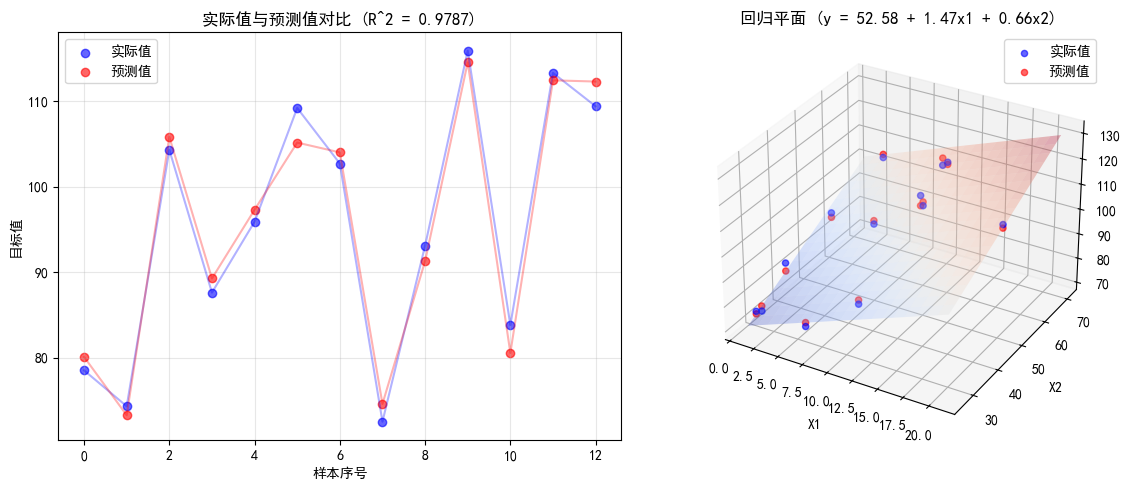

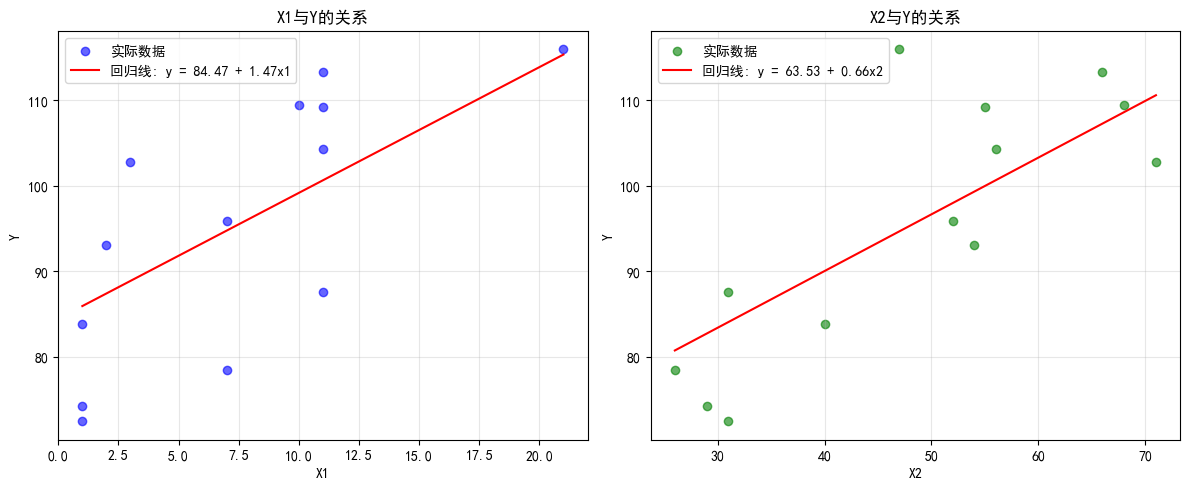

截距 b0: 52.5773
回归系数 b1: 1.4683, b2: 0.6623
复判定系数 R²: 0.9787


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# 读取数据并训练模型
a = np.loadtxt("Pdata12_1.txt")
X = a[:, :2]
y_true = a[:, 2]

model = LinearRegression()
model.fit(X, y_true)
y_pred = model.predict(X)

b0 = model.intercept_
b1, b2 = model.coef_
R2 = model.score(X, y_true)

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 1. 实际值与预测值对比图
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.scatter(range(len(y_true)), y_true, c='blue', label='实际值', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, c='red', label='预测值', alpha=0.6)
plt.plot(range(len(y_true)), y_true, 'b-', alpha=0.3)
plt.plot(range(len(y_pred)), y_pred, 'r-', alpha=0.3)
plt.xlabel('样本序号')
plt.ylabel('目标值')
plt.title(f'实际值与预测值对比 (R^2 = {R2:.4f})')
plt.legend()
plt.grid(alpha=0.3)

# 2. 3D散点图与回归平面
ax = plt.subplot(122, projection='3d')

# 绘制数据点
ax.scatter(X[:, 0], X[:, 1], y_true, c='blue', label='实际值', alpha=0.6)
ax.scatter(X[:, 0], X[:, 1], y_pred, c='red', label='预测值', alpha=0.6)

# 生成网格数据用于绘制回归平面
x1_range = np.linspace(X[:, 0].min(), X[:, 0].max(), 20)
x2_range = np.linspace(X[:, 1].min(), X[:, 1].max(), 20)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
y_grid = b0 + b1 * x1_grid + b2 * x2_grid

# 绘制回归平面
surf = ax.plot_surface(x1_grid, x2_grid, y_grid, cmap='coolwarm', alpha=0.3)

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.set_title(f'回归平面 (y = {b0:.2f} + {b1:.2f}x1 + {b2:.2f}x2)')
ax.legend()

plt.tight_layout()
plt.show()

# 3. 各特征与目标值的关系图（带回归线）
plt.figure(figsize=(12, 5))

# X1与Y的关系
plt.subplot(121)
plt.scatter(X[:, 0], y_true, c='blue', alpha=0.6, label='实际数据')
x1_line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
# 固定X2为平均值来绘制X1的回归线
y1_line = b0 + b1 * x1_line + b2 * np.mean(X[:, 1])
plt.plot(x1_line, y1_line, 'r-', label=f'回归线: y = {b0 + b2*np.mean(X[:,1]):.2f} + {b1:.2f}x1')
plt.xlabel('X1')
plt.ylabel('Y')
plt.title('X1与Y的关系')
plt.legend()
plt.grid(alpha=0.3)

# X2与Y的关系
plt.subplot(122)
plt.scatter(X[:, 1], y_true, c='green', alpha=0.6, label='实际数据')
x2_line = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
# 固定X1为平均值来绘制X2的回归线
y2_line = b0 + b1 * np.mean(X[:, 0]) + b2 * x2_line
plt.plot(x2_line, y2_line, 'r-', label=f'回归线: y = {b0 + b1*np.mean(X[:,0]):.2f} + {b2:.2f}x2')
plt.xlabel('X2')
plt.ylabel('Y')
plt.title('X2与Y的关系')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 输出模型参数
print(f"截距 b0: {b0:.4f}")
print(f"回归系数 b1: {b1:.4f}, b2: {b2:.4f}")
print(f"复判定系数 R²: {R2:.4f}")


### 2. `statsmodels` 库求解

statsmodels 可以使用两种模式求解回归分析模型，一种是基于公式的模式，另－种是基于数组的模式．  
基于**公式**构建并拟合模型的调用格式为
```python
import statsmodels as sm 
sm.formula.ols(formula, data=df) 
```
其中， formula 为引号括起来的公式， df 为数据框或字典格式的数据．

基于**数组**构建并拟合模型的调用格式为
```python
import statsmodels.api as sm 
sm. OLS (y,X). fit() 
```
其中， y 为因变量的观察值向量， X 为自变量观测值矩阵再添加第一列全部元素为1 得到的增广阵

In [10]:
# 基于公式求解
import numpy as np
import statsmodels.api as sm

a = np.loadtxt("Pdata12_1.txt")
d = {'x1': a[:, 0], 'x2': a[:, 1], 'y': a[:, 2]}

md = sm.formula.ols('y ~ x1 + x2', d)
results = md.fit()

print(results.summary(), '\n---------------\n')  # 显示模型所有信息

y_pred = results.predict({'x1': a[:, 0], 'x2': a[:, 1]})

print(a[:, 2].reshape(13, 1))
print(y_pred)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     229.5
Date:                Fri, 15 Aug 2025   Prob (F-statistic):           4.41e-09
Time:                        21:20:00   Log-Likelihood:                -28.156
No. Observations:                  13   AIC:                             62.31
Df Residuals:                      10   BIC:                             64.01
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     52.5773      2.286     22.998      0.0

d:\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=13
  res = hypotest_fun_out(*samples, **kwds)


要理解这份 **OLS回归结果表（普通最小二乘法）**，需要从表格结构和统计学核心指标两方面拆解。这份结果是对“y与x1、x2的线性回归模型（y = 52.5773 + 1.4683x1 + 0.6623x2）”的全面评估，每一部分都对应模型的不同特性，下面逐块详解：


### 一、顶部基础信息：模型整体框架
这部分是回归的“基本身份信息”，明确模型类型、目标变量和核心方法。

| 指标                | 含义解释                                                                 |
|---------------------|--------------------------------------------------------------------------|
| Dep. Variable: y     | **被解释变量（因变量）**：我们要预测或解释的变量，这里是y。               |
| Model: OLS           | **模型类型**：普通最小二乘法（Ordinary Least Squares），最常用的线性回归方法，核心是最小化“实际y与预测y的误差平方和”。 |
| Method: Least Squares | **求解方法**：与OLS对应，通过最小化残差平方和得到回归系数。               |
| Date/Time           | 模型拟合的时间，无统计学意义，仅记录用途。                               |
| No. Observations: 13 | **样本量**：用于拟合模型的数据有13组（即Pdata12_1.txt中有13行数据）。    |
| Df Model: 2          | **模型自由度**：等于自变量个数（x1、x2共2个），代表模型中“可自由调整的参数维度”。 |
| Df Residuals: 10     | **残差自由度**：样本量 - 模型自由度 - 1（截距项占1个自由度）= 13-2-1=10，用于后续显著性检验（如t检验、F检验）。 |


### 二、核心拟合优度指标：模型“好不好用”
这部分评估模型对数据的**解释能力**——即x1、x2能多大程度上解释y的变化。

| 指标                | 含义解释                                                                 |
|---------------------|--------------------------------------------------------------------------|
| R-squared: 0.979     | **判定系数**：核心指标！表示“y的总变异中，被x1、x2共同解释的比例”。<br>0.979意味着：**y的97.9%变化能被x1和x2的线性组合解释**，属于极高的拟合优度（越接近1越，0表示完全无法解释）。 |
| Adj. R-squared: 0.974| **调整后判定系数**：对R²的修正（避免“加无关自变量导致R²虚高”）。<br>公式：Adj-R² = 1 - [(1-R²)*(n-1)/(n-k-1)]（n=样本量，k=自变量数）。<br>这里0.974仍极高，明即使修正后，模型解释力依然很强，x1、x2都是有效自变量。 |
| F-statistic: 229.5   | **F统计量**：检验“所有自变量的系数是否同时为0”（即“模型整体是否显著”）。<br>原假设：β1=β2=0（x1、x2对y无影响）；备择假设：至少一个β≠0。 |
| Prob (F-statistic): 4.41e-09 | **F检验的p值**：判断F统计量的显著性。<br>4.41e-09 ≈ 0（远小于0.05的常用显著性水平），说明**原假设被拒绝**——x1和x2联合起来对y有极显著的解释作用，模型体有效。 |


### 三、回归系数表：自变量对y的“具体影响”
这部分是回归的核心输出——明确x1、x2如何影响y，以及影响是否显著。

|   系数项       | coef（系数） | std err（标准误） | t（t统计量） | P>|t|（p值） | [0.025, 0.975]（95%置信区间） |

|--------------|--------------|-------------------|--------------|--------------|--------------------------------|

| Intercept    | 52.5773      | 2.286             | 22.998       | 0.000        | [47.483, 57.671]               |

| x1           | 1.4683       | 0.121             | 12.105       | 0.000        | [1.198, 1.739]                 |

| x2           | 0.6623       | 0.046             | 14.442       | 0.000        | [0.560, 0.764]                 |

逐个解释关键列：
1. **coef（回归系数）**：  
   - Intercept（截距项β0）：52.5773——当x1=0、x2=0时，y的预测值为52.5773（需结合数据实际含义，若x1/x2不可能为0，截距仅为数学参数）。  
   - x1的系数（β1）：1.4683——**在x2固定时，x1每增加1个单位，y平均增加1.4683个单位**（正相关）。  
   - x2的系数（β2）：0.6623——**在x1固定时，x2每增加1个单位，y平均增加0.6623个单位**（正相关）。  

2. **std err（标准误）**：系数的估计误差，越小说明系数估计越稳定（这里x1、x2的标准误都很小，估计可靠）。  

3. **t（t统计量）**：检验“单个系数是否为0”（即“该自变量对y是否有显著影响”），公式：t = (系数 - 0)/标准误。  

4. **P>|t|（t检验的p值）**：  
   - 所有项的p值均为0.000（远小于0.05），说明**截距项和两个自变量的系数均显著非0**——x1、x2单独对y的影响也极显著，没有“无关自变量”。  

5. **95%置信区间**：  
   - 表示“有95%的把握，真实系数落在这个区间内”（如x1的真实系数在1.198~1.739之间），区间不包含0，进一步验证系数显著。


### 四、残差检验：模型“假设是否成立”
OLS回归有4个核心假设（线性、同方差、无自相关、正态性），这部分通过残差（实际y - 预测y）检验假设是否满足。

| 指标                | 含义解释                                                                 |
|---------------------|--------------------------------------------------------------------------|
| Omnibus: 1.509      | **Omnibus检验**：检验残差是否服从正态分布（结合偏度和峰度）。<br>统计量越小，越接近正态分布（1.509属于较小值）。 |
| Prob(Omnibus): 0.470| Omnibus检验的p值（0.470 > 0.05），说明**无法拒绝“残差正态分布”的假设**，满足正态性假设。 |
| Skew: 0.503         | **偏度**：衡量残差分布的不对称性。<br>0为完全对称，0.503接近0，说明残差分布基本对称（无明显偏斜）。 |
| Kurtosis: 1.987     | **峰度**：衡量残差分布的“陡峭程度”。<br>正态分布峰度为3，1.987略低（属于“低峰分布”），但结合Omnibus的p值，偏差可接受。 |
| Jarque-Bera (JB): 1.104 | **JB检验**：另一种正态性检验，基于偏度和峰度。<br>统计量越小，越接近正态分布。 |
| Prob(JB): 0.576     | JB检验的p值（0.576 > 0.05），再次验证**残差服从正态分布**，模型假设成立。 |
| Durbin-Watson: 1.922 | **DW检验**：检验残差是否存在“自相关”（即相邻残差是否相关，常见于时间序列数据）。<br>DW值接近2（这里1.922），说明**残差无显著自相关**，满足无自相关假设。 |
| Cond. No.: 175      | **条件数**：检验“多重共线性”（即x1和x2是否高度相关，导致系数估计不稳定）。<br>一般认为：<200无严重共线性，200~1000需警惕，>1000严重。<br>175属于安全范围，说明x1和x2无严重多重共线性，系数估计可靠。 |


### 五、底部注释：补充说明
- **Notes: [1] Standard Errors assume that the covariance matrix of the errors is correctly specified.**  
  含义：“本结果中的标准误，基于‘残差协方差矩阵设定正确’的假设（即假设残差满足同方差、无自相关）”。结合前面的DW检验和Omnibus检验，这个假设是成立的，因此标准误和p值都是可靠的。


### 总结：这份回归结果的核心结论
1. **模型整体优秀**：R²=0.979，F检验极显著，x1和x2能解释y的97.9%变化，整体有效。  
2. **变量影响显著**：x1每增1单位，y增1.4683；x2每增1单位，y增0.6623，且两个影响均极显著。  
3. **假设均满足**：残差正态、无自相关、无严重多重共线性，模型假设成立，结果可信。  

简单说：这是一个拟合效果极佳、解释力强、假设满足的可靠线性回归模型，可以用y = 52.5773 + 1.4683x1 + 0.6623x2来预测y。

In [ ]:
# 数组求解
import numpy as np
import statsmodels.api as sm

a = np.loadtxt("Pdata12_1.txt")
X = sm.add_constant(a[:, :2])  # 增加第一列全部元素为1得到增广矩阵
md = sm.OLS(a[:, 2], X).fit()

print(md.params, '\n-------------\n')  # 提取所有回归系数[截距, x1的系数, x2的系数]

y = md.predict(X)

print(a[:, 2].reshape(13, 1))
print(y.reshape(13, 1))

[52.57734888  1.46830574  0.66225049] 
-------------

[[ 78.5]
 [ 74.3]
 [104.3]
 [ 87.6]
 [ 95.9]
 [109.2]
 [102.7]
 [ 72.5]
 [ 93.1]
 [115.9]
 [ 83.8]
 [113.3]
 [109.4]]
[[ 80.07400185]
 [ 73.25091887]
 [105.81473956]
 [ 89.25847728]
 [ 97.29251462]
 [105.15248907]
 [104.00205099]
 [ 74.57541985]
 [ 91.2754869 ]
 [114.53754256]
 [ 80.53567428]
 [112.43724447]
 [112.29343971]]
